<div>
<img src=https://www.institutedata.com/wp-content/uploads/2019/10/iod_h_tp_primary_c.svg width="300">
</div>

# Lab 6.1.1: K-Means by the algorithm

### Australian athletes data set

##### Description
These data were collected in a study of how data on various characteristics of the blood varied with sport, body size, and sex of the athlete.

Usage
data(ais)
Format
A data frame with 202 observations on the following 13 variables.

rcc
red blood cell count, in

wcc
white blood cell count, in per liter

hc
hematocrit, percent

hg
hemaglobin concentration, in g per decaliter

ferr
plasma ferritins, ng

bmi
Body mass index, kg

ssf
sum of skin folds

pcBfat
percent Body fat

lbm
lean body mass, kg

ht
height, cm

wt
weight, kg

sex
a factor with levels f m

sport
a factor with levels B_Ball Field Gym Netball Row Swim T_400m T_Sprnt Tennis W_Polo

Source
These data were the basis for the analyses that are reported in Telford and Cunningham (1991).

References
Telford, R.D. and Cunningham, R.B. 1991. Sex, sport and body-size dependency of hematology in highly trained athletes. Medicine and Science in Sports and Exercise 23: 788-794.

**References**

[Data](http://vincentarelbundock.github.io/Rdatasets/csv/DAAG/ais.csv)

[Data Dictionary](http://vincentarelbundock.github.io/Rdatasets/doc/DAAG/ais.html)

In [21]:
# Set the number of threads to be 1 for K Means to proceed without warnings
import os
os.environ['OMP_NUM_THREADS'] = '1'


In [22]:
# IMPORT LIBRA# The math and data heavyweights
import numpy as np
import pandas as pd

# The clustering muscle
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# The visualization duo
import matplotlib.pyplot as plt
import seaborn as snsRIES

### 1. Import the data

In [23]:
csv_file = 'ais.csv'

### 2. Do some EDA of relationships between features.

In [24]:
df = pd.read_csv(csv_file)
df.head()

,Unnamed: 0,rcc,wcc,hc,hg,ferr,bmi,ssf,pcBfat,lbm,ht,wt,sex,sport
0,1,3.96,7.5,37.5,12.3,60,20.56,109.1,19.75,63.32,195.9,78.9,f,B_Ball
1,2,4.41,8.3,38.2,12.7,68,20.67,102.8,21.30,58.55,189.7,74.4,f,B_Ball
2,3,4.14,5.0,36.4,11.6,21,21.86,104.6,19.88,55.36,177.8,69.1,f,B_Ball
3,4,4.11,5.3,37.3,12.6,69,21.88,126.4,23.66,57.18,185.0,74.9,f,B_Ball
4,5,4.45,6.8,41.5,14.0,29,18.96,80.3,17.64,53.20,184.6,64.6,f,B_Ball


In [25]:
df.shape

(202, 14)

### 3. Prepare the data for clustering

1. Remove the `sex`, `sport` column. We will see if the clusters from K-Means end up like the actual sex.
2. Put the features on the same scale.

In [26]:
df = df.drop(columns=['sex', 'sport'])
df.to_csv('ais_cleaned.csv', index=False)

X = df.drop(columns=['Unnamed: 0']) if 'Unnamed: 0' in df.columns else df.copy()

### 4. Clustering with K-Means

- Cluster the data to our target groups.
    - Use sklearn.cluster.KMeans
- We know that there are 2 actual classes. Let's try using 2, 4 clusters. Run the clustering algorithm with each of those k values.

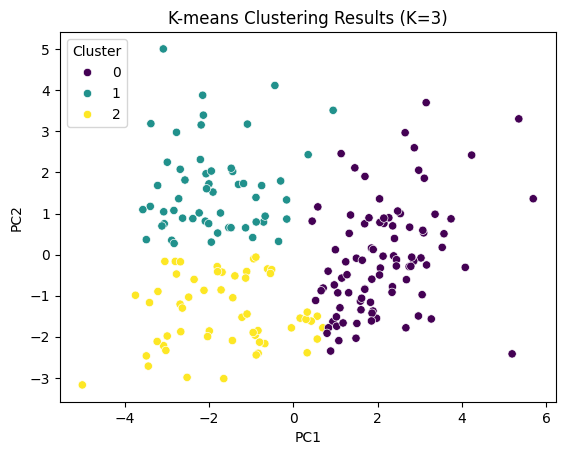

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Finding the optimal K (Elbow Method)
wcss = [] # Within-cluster sum of squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# 4. Fit the model with the chosen number of clusters (e.g., k=3)
k = 3
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 5. Visualization using PCA (Reducing 11 variables to 2 for plotting)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['Cluster']

# Plotting the results
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', palette='viridis')
plt.title(f'K-means Clustering Results (K={k})')
plt.show()

# Save the final results
df.to_csv('ais_clustered.csv', index=False)

### 5. Get the labels for the models using the labels_ attribute.

In [30]:
cluster_labels = kmeans.labels_

print(cluster_labels[:10])

[1 1 1 1 2 2 1 1 1 2]


### 6. Elbow Method For Optimal k

For each k value, we will initialize k-means and use the inertia attribute to identify the sum of squared distances of samples to the nearest cluster centre. As k increases, the sum of squared distance tends to zero.

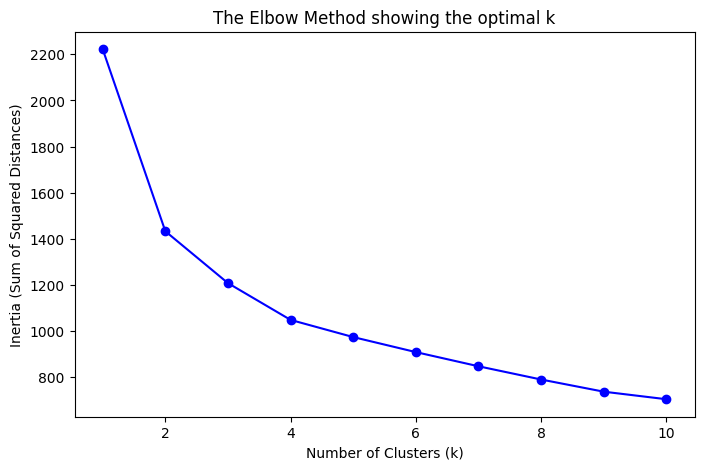

In [31]:
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    # Initialize KMeans with the current k
    model = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    model.fit(X_scaled)
    
    # Append the inertia attribute to our list
    inertia_values.append(model.inertia_)

# Plotting the results to find the "Elbow"
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('The Elbow Method showing the optimal k')
plt.show()

Below is a plot of sum of squared distances for k in the range specified above. If the plot looks like an arm, then the elbow on the arm is optimal k.

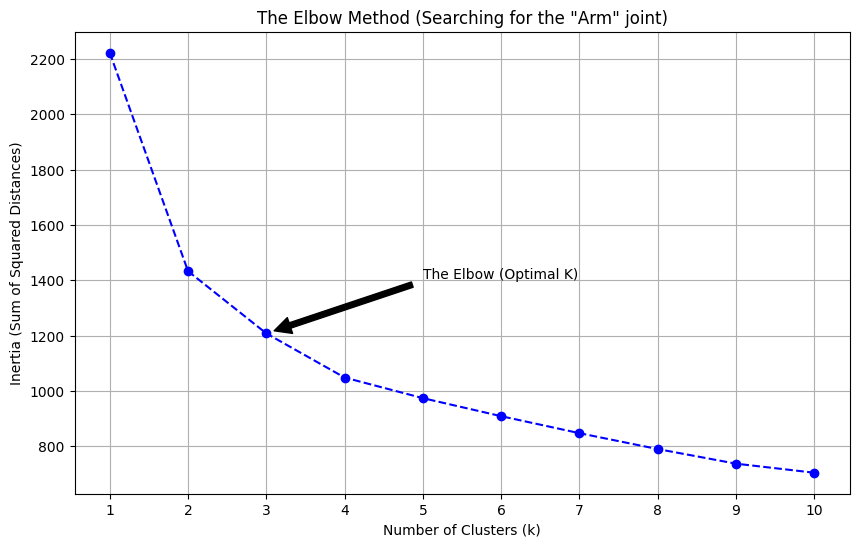

In [36]:
inertia_list = []
k_range = range(1, 11)

# 2. Loop through k values
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled) # Use your scaled numeric data here
    inertia_list.append(kmeans.inertia_)

# 3. Create the "Arm" Plot
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_list, marker='o', color='b', linestyle='--')
plt.title('The Elbow Method (Searching for the "Arm" joint)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.xticks(k_range)

# Annotate the "Elbow" (usually around 3 for this dataset)
plt.annotate('The Elbow (Optimal K)', xy=(3, inertia_list[2]), xytext=(5, inertia_list[2]+200),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.grid(True)
plt.show()

### 7. Plot `wt` vs. `pcBfat` using the clusters from each model.

- Plot wt, pcBfat using hue sex
- Plot wt, pcBfat using hue label

The labels calculated above can be a new column of the dataset.

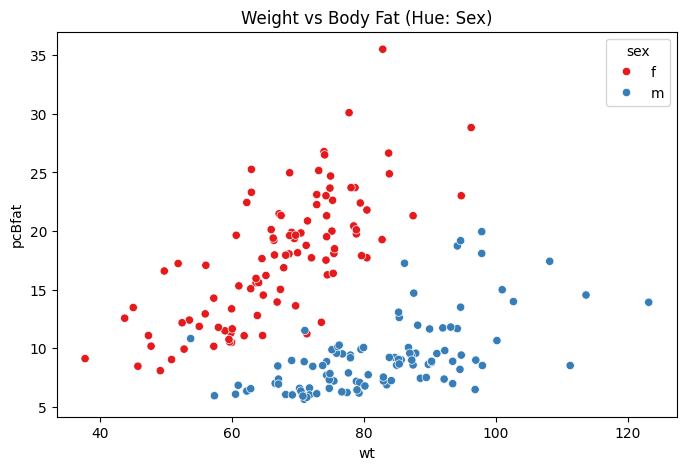

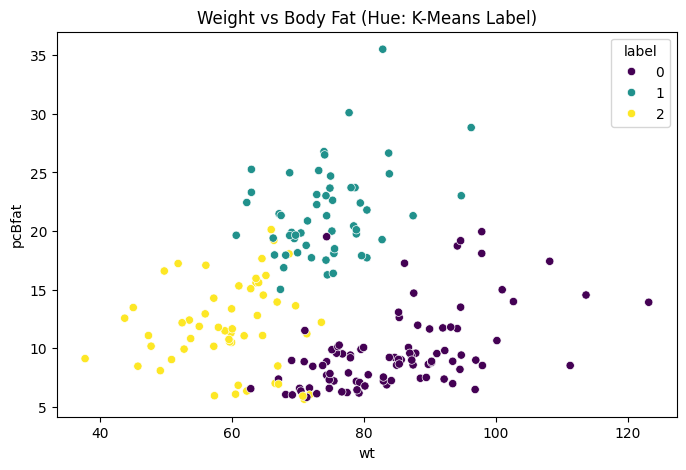

In [39]:
df = pd.read_csv('ais.csv')

# 2. Prepare numeric data for clustering
# We drop 'sex' and 'sport' because K-means only works with numbers
X = df.drop(columns=['sex', 'sport'])
if 'Unnamed: 0' in X.columns:
    X = X.drop(columns=['Unnamed: 0'])

# 3. Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Fit the model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# 5. DEFINE THE LABELS (This solves the NameError)
labels = kmeans.labels_

# 6. Add labels back to the dataframe for plotting
df['label'] = labels

# --- PLOTTING ---

# Plot 1: Using the original 'sex' column
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='wt', y='pcBfat', hue='sex', palette='Set1')
plt.title('Weight vs Body Fat (Hue: Sex)')
plt.show()

# Plot 2: Using the newly created 'label' variable
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='wt', y='pcBfat', hue='label', palette='viridis')
plt.title('Weight vs Body Fat (Hue: K-Means Label)')
plt.show()



---



---



> > > > > > > > > © 2026 Institute of Data


---



---



